<h1 style="text-align:center;color:blue;font-size:30px;font-family:times">Ecole Nationale de la Statistique et de l'Analyse Economique Pierre NDIAYE (ENSAE)</h1><br>

<h1 style="text-align:center;color:yellow;font-size:50px;font-family:ALGERIAN;border:solid">Projet de Machine Learning</h1>

<h1 style="text-align:center;color:brown;font-size:50px;font-family:ALGERIAN;border:solid">House prices prediction</h1>

<div style="display:flex;text-align:justify">
    
    
<ul style="text-align:justify;font-family:times;font-size:15px;list-style-type:circle; width:60%"> 
<span style="font-weight:bold">Réalisé par </span> 
    <ul style="text-align:justify;font-family:times;font-size:15px;list-style-type:circle"> 
        <li>Traoré sié rachid</li>                         
        <li>Sarr el hadj mum</li> 
        <li>Traoré sié rachid</li>                          
        <li>Sarr el hadj mum</li> 
    </ul>
    <span style="font-style: italic;font-size:13px">Élèves Ingénieurs Statisticiens Economistes</span>
</ul>
 
<ul style="text-align:justify;font-family:times;font-size:15px;list-style-type:none;width:39%"> 
 <li style="font-weight:bold">Sous la supervision de:</li> 
 <li>Mme Mously Diaw</li>
    <span style="font-style: italic;font-size:13px">Senior Machine learning Engineer, Entrepreneure @Sen-IA
    </span>
   
</ul>
    
</div>   

![](https://etimg.etb2bimg.com/photo/78036515.cms)

> <p style="text-align:justify;font-family:times;font-size:18px;font-style: italic;font-family:Century Schoolbook">
   La structure du projet est bien définie dans le fichier Readme. Notre objectif ici est de réaliser l'analyse exploratoire des données.</p>

<h1 style="text-align:center;color:yellow;font-size:50px;font-family:ALGERIAN;border:solid">ANALYSE EXPLORATOIRE DES DONNEES</h1>

<h2 style="text-align:justify;color:bright;font-size:30px;font-family:TIMES NEW ROMAN">I. Importation des packages</h2>

In [9]:
#!pip install missingno
import numpy as np  # Manipulation des tableaux et calculs numériques.
import pandas as pd  # Manipulation et analyse de données, notamment les DataFrames.
import matplotlib.pyplot as plt  # Création de graphiques statiques (courbes, histogrammes, scatter plots).
import matplotlib.style as style
import seaborn as sns  # Visualisation statistique, permet de créer des graphiques plus esthétiques et informatifs.
import missingno as msno  # Visualisation des données manquantes.
from scipy import stats

<h2 style="text-align:justify;color:bright;font-size:30px;font-family:TIMES NEW ROMAN">II. CHARGEMENT DES DONNEES</h2>

---
> <p style="text-align:justify;font-family:times;font-size:18px;font-style: italic;font-family:Century Schoolbook">
   Dans les données brutes, Nous avons le jeu de donnée "train" pour l'entrainement et "test" pour l'évaluation du modèle.</p>
---

In [12]:
train=pd.read_csv("../data/train.csv", sep=";")
print(train.shape)
train.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [13]:
test=pd.read_csv("../data/test.csv",sep=";")
print(test.shape)
test.head()

(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


---
> <p style="text-align:justify;font-family:times;font-size:18px;font-style: italic;font-family:Century Schoolbook">
   test contient 80 variables et 1459 observations et train contient 81 variables (la colonne SalePrice vient de plus) et 1460 observations.
   Nous allons faire toute l'analyse sur le train.</p>
---

<h2 style="text-align:justify;color:bright;font-size:30px;font-family:TIMES NEW ROMAN">III. NETTOYAGE DES DONNEES</h2>

In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [17]:
train.drop("Id",axis=1,inplace=True)

In [18]:
def missing(df):
    plt.figure(figsize=(10, 6))
    msno.matrix(df)
    plt.title('Matrice des valeurs manquantes')
    plt.show()
    
    plt.figure(figsize=(10, 6))
    msno.bar(df)
    plt.title('Barre des valeurs manquantes')
    plt.show()
    
    missing_counts = df.isnull().sum().sort_values(ascending=False)
    missing_counts = missing_counts[missing_counts > 0] 
    
    missing_percent = round((missing_counts / len(df)) * 100, 2)
    
    missing_summary = pd.concat([missing_counts, missing_percent], axis=1, keys=['Total', 'Percent'])
    
    return missing_summary

<Figure size 1000x600 with 0 Axes>

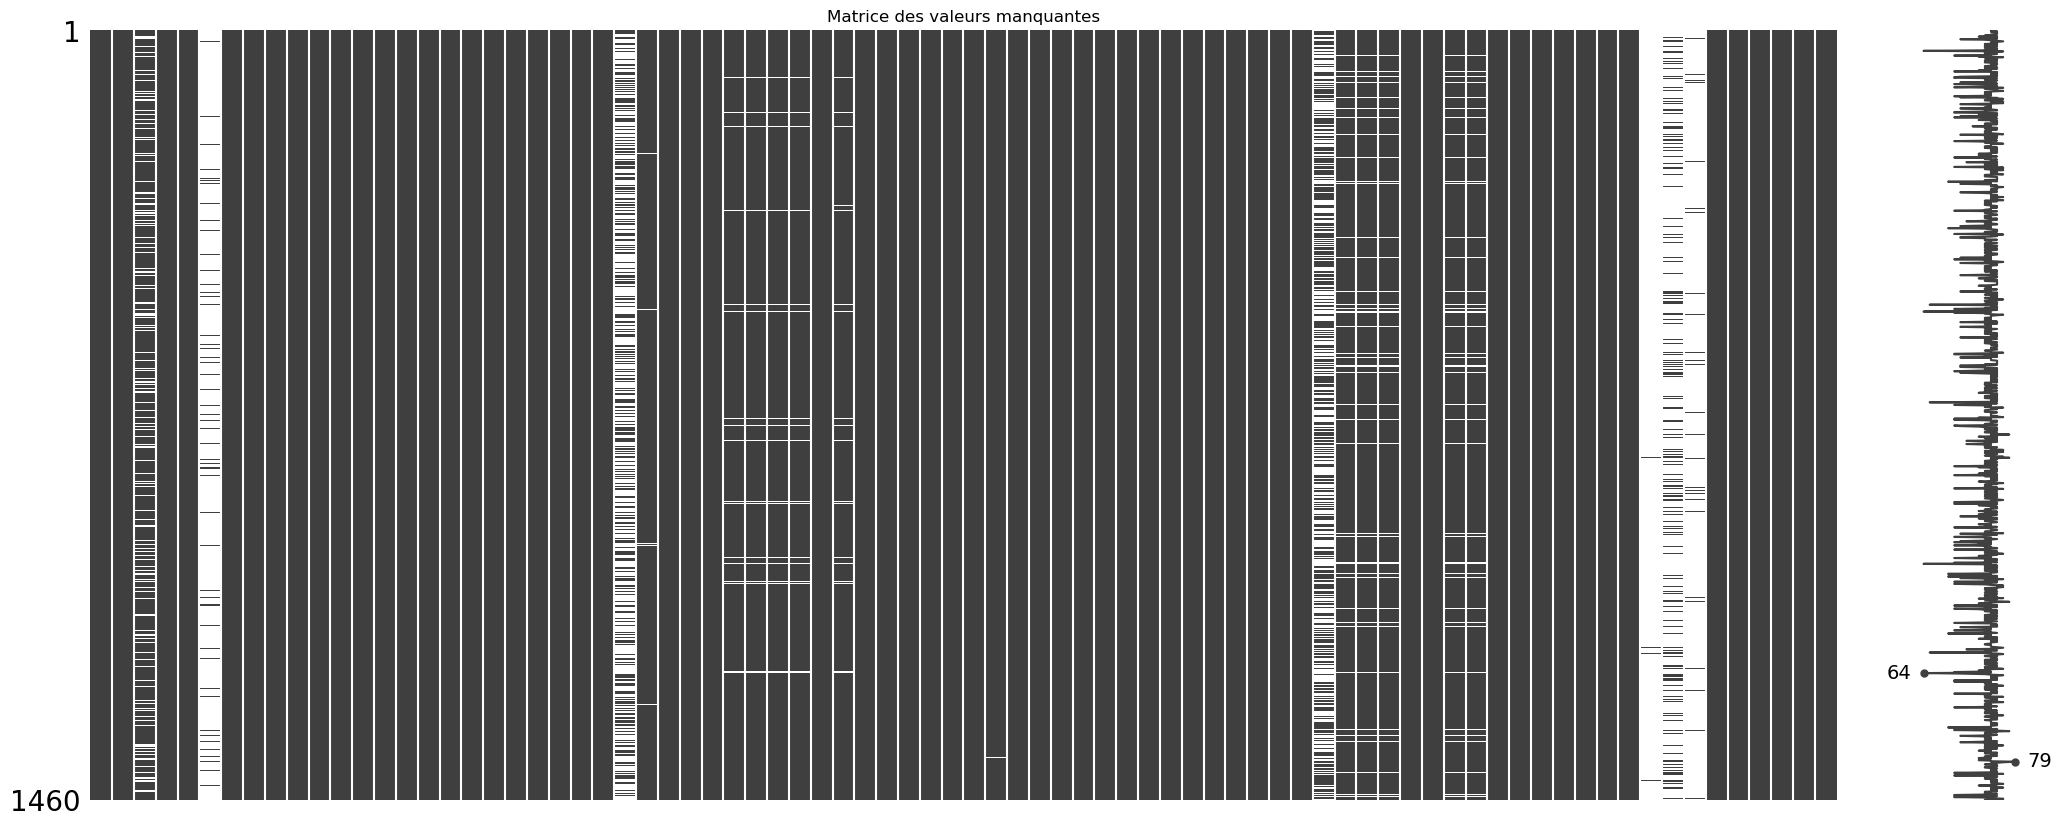

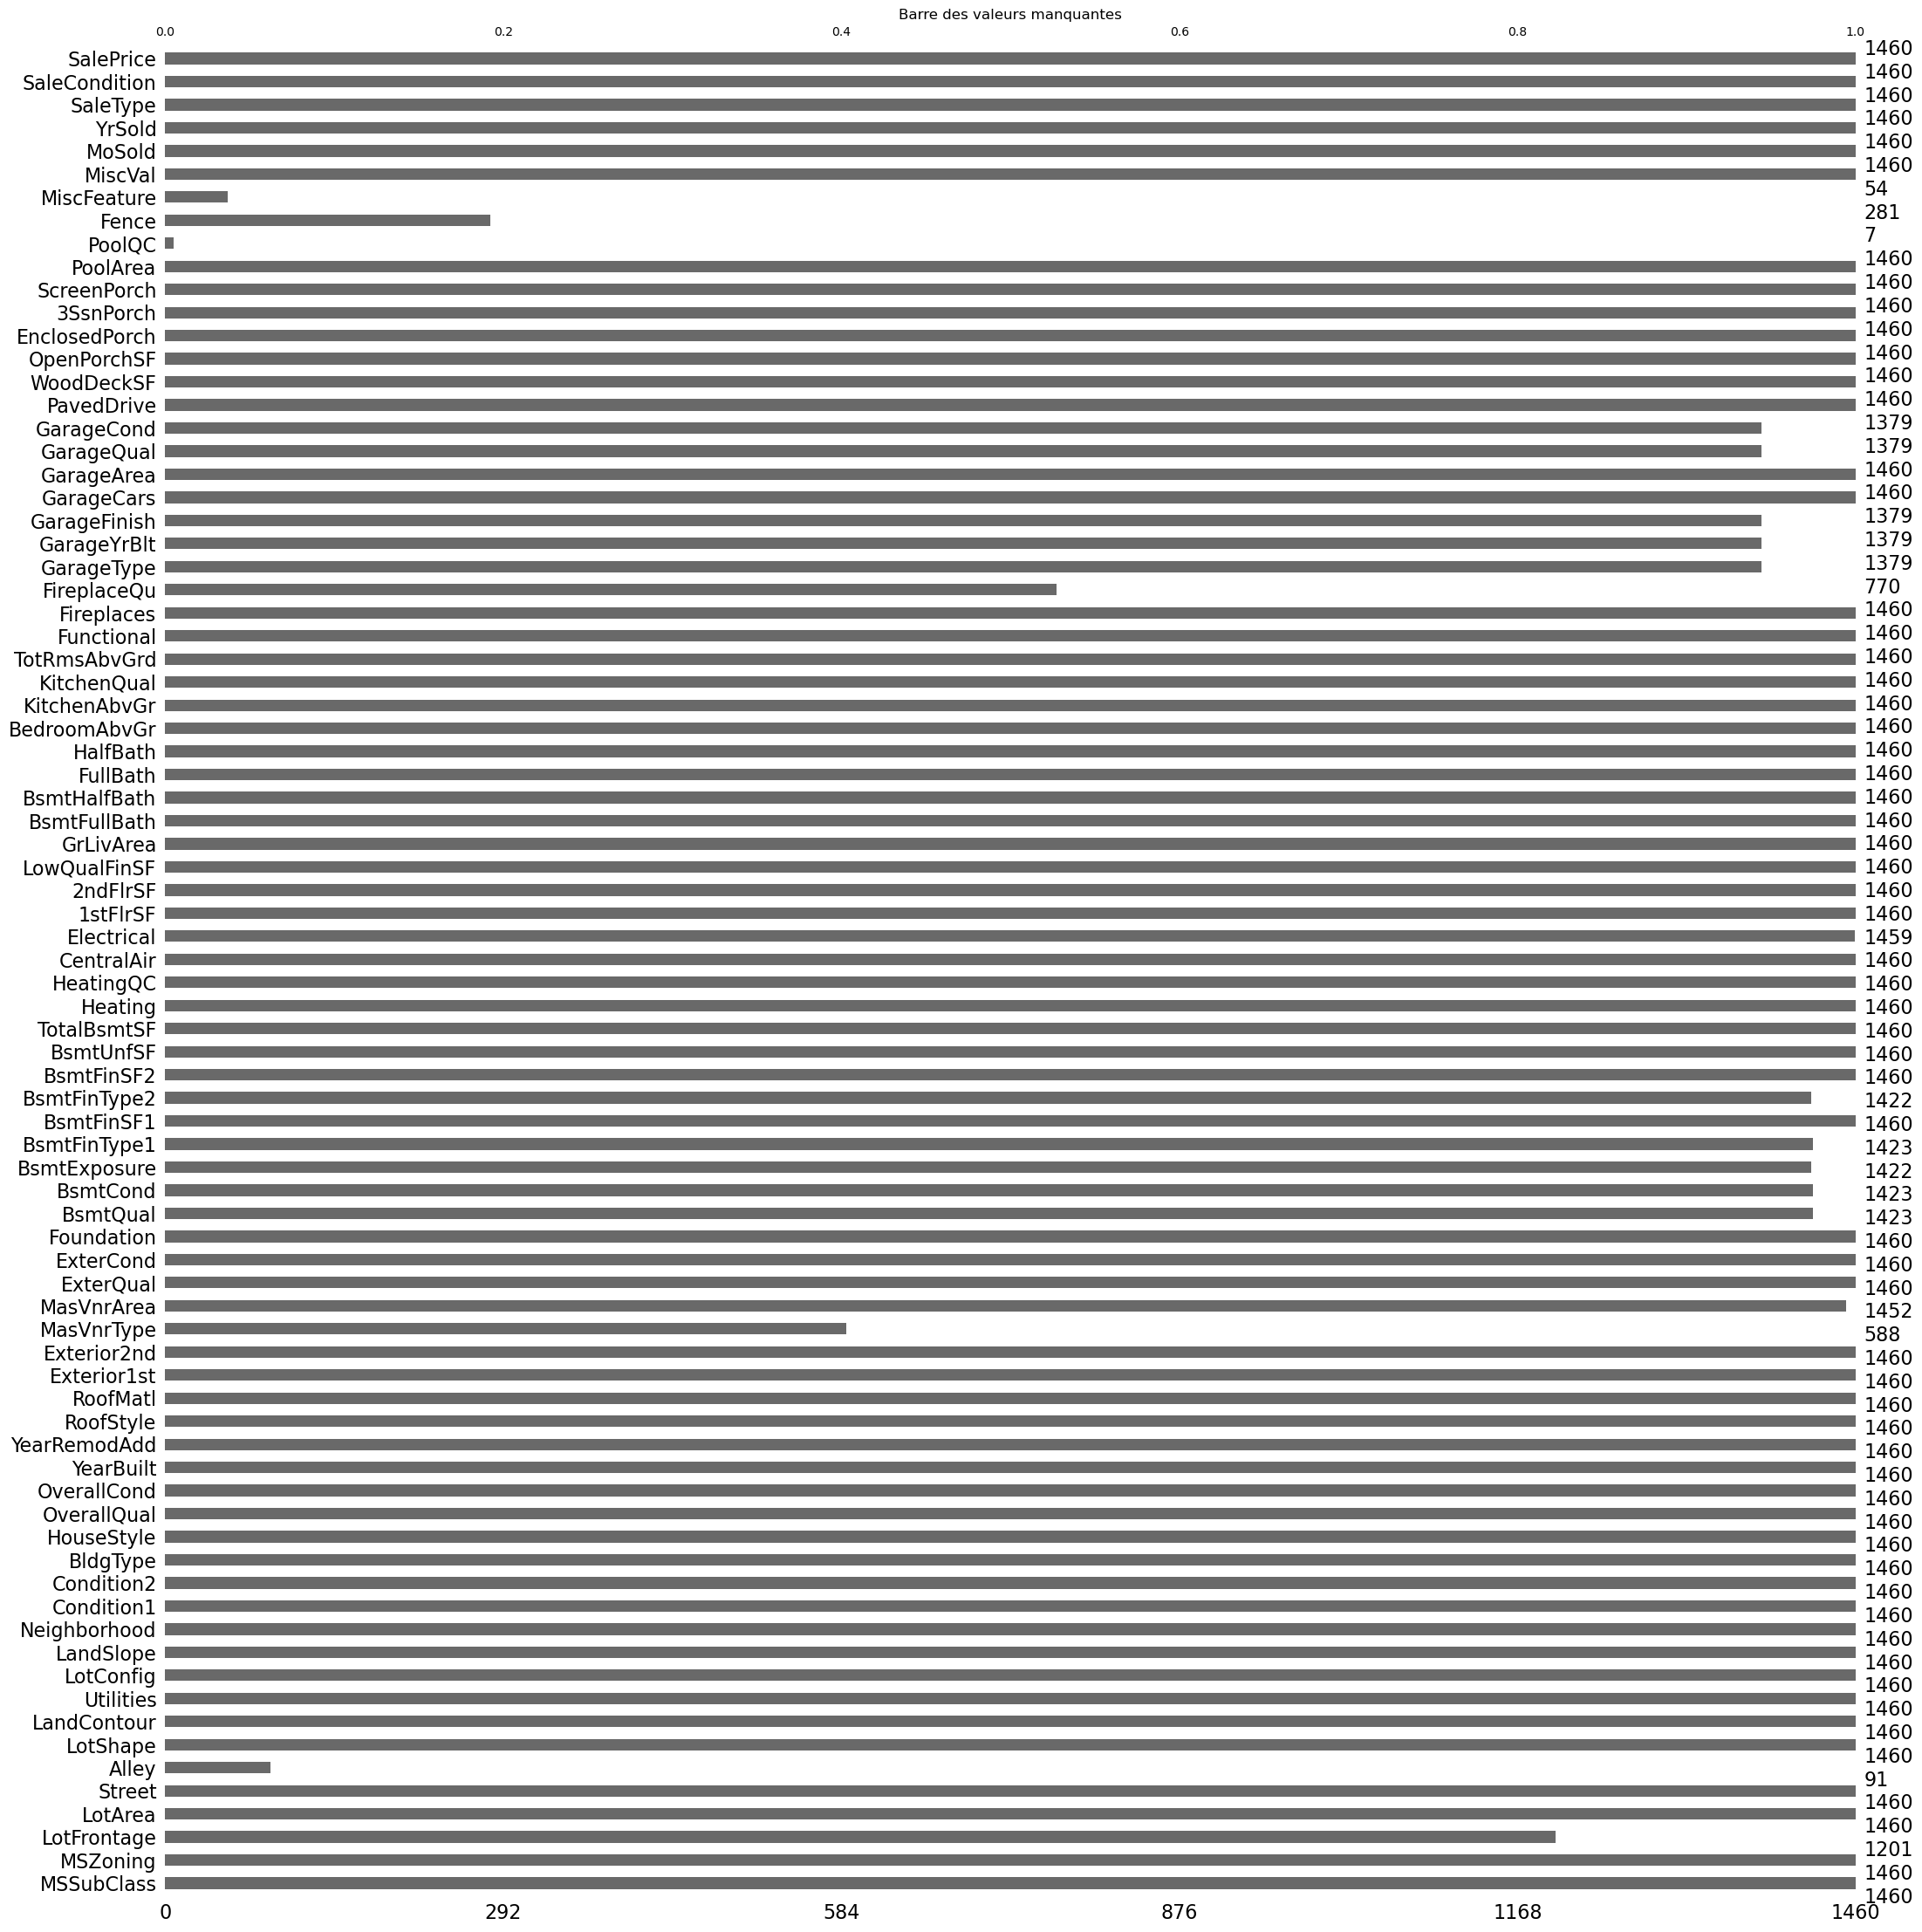

,Total,Percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageCond,81,5.55
GarageType,81,5.55


In [19]:
missing(train)

---
> <p style="text-align:justify;font-family:times;font-size:18px;font-style: italic;font-family:Century Schoolbook">
   Ainsi, les variables ci-dessus constituent les variables contenant des valeurs manquantes. Nous pouvons aussi constater les fréquences valeurs des manquantes.
   Toutefois attention, pour certaines valeurs manquantes comptées sont en réalité des valeurs non applicables.Pour cela il faut considérer le fichier descrition txt
Par exemple, la variable PoolQC qui décrit la qualité de la piscine a les modalités suivantes:
    <ul style="text-align:justify;font-family:times;font-size:15px;list-style-type:point"> 
        <li>Ex: Excellent</li>                         
        <li>Gd: Good</li> 
        <li>TA: Average/Typical</li>  
        <li>Fa: Fair</li> 
        <li>NA: No Pool</li> 
 </p>
> <p style="text-align:justify;font-family:times;font-size:18px;font-style: italic;font-family:Century Schoolbook">
Un autre, c'est la variable Alley qui décrit le type d'accès par ruelle à la propriété a les modalités suivantes:
    <ul style="text-align:justify;font-family:times;font-size:15px;list-style-type:point"> 
        <li>Grvl:Gravel (Gravillon)</li>                         
        <li>Pave:Paved (Pavé) </li> 
        <li>NA: No alley access (pas d'accès par ruelle)</li>   
    </ul>.
    </p>
> <p style="text-align:justify;font-family:times;font-size:18px;font-style: italic;font-family:Century Schoolbook">
    il nous faut donc les changer en None.
---

In [21]:
missing_val_col = ["Alley", 
                   "PoolQC", 
                   "MiscFeature",
                   "Fence",
                   "FireplaceQu",
                   "GarageType",
                   "GarageFinish",
                   "GarageQual",
                   "GarageCond",
                   'BsmtQual',
                   'BsmtCond',
                   'BsmtExposure',
                   'BsmtFinType1',
                   'BsmtFinType2',
                   'MasVnrType']
for i in missing_val_col:
    train[i] = train[i].fillna('None')

<Figure size 1000x600 with 0 Axes>

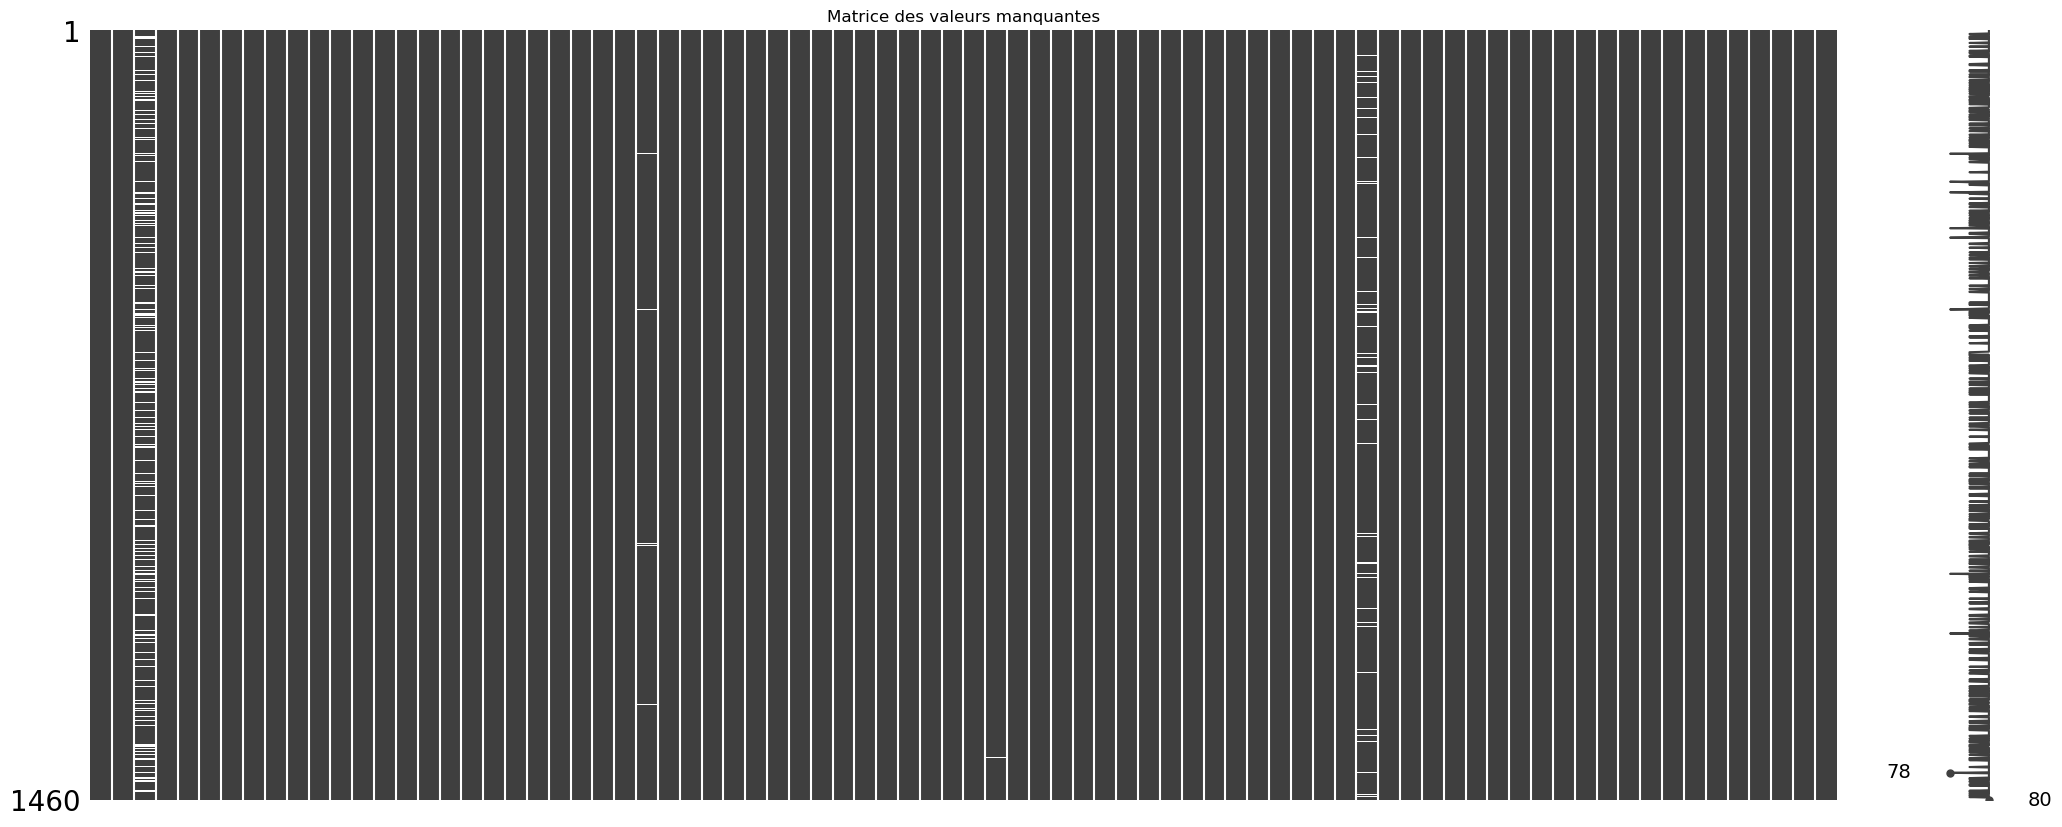

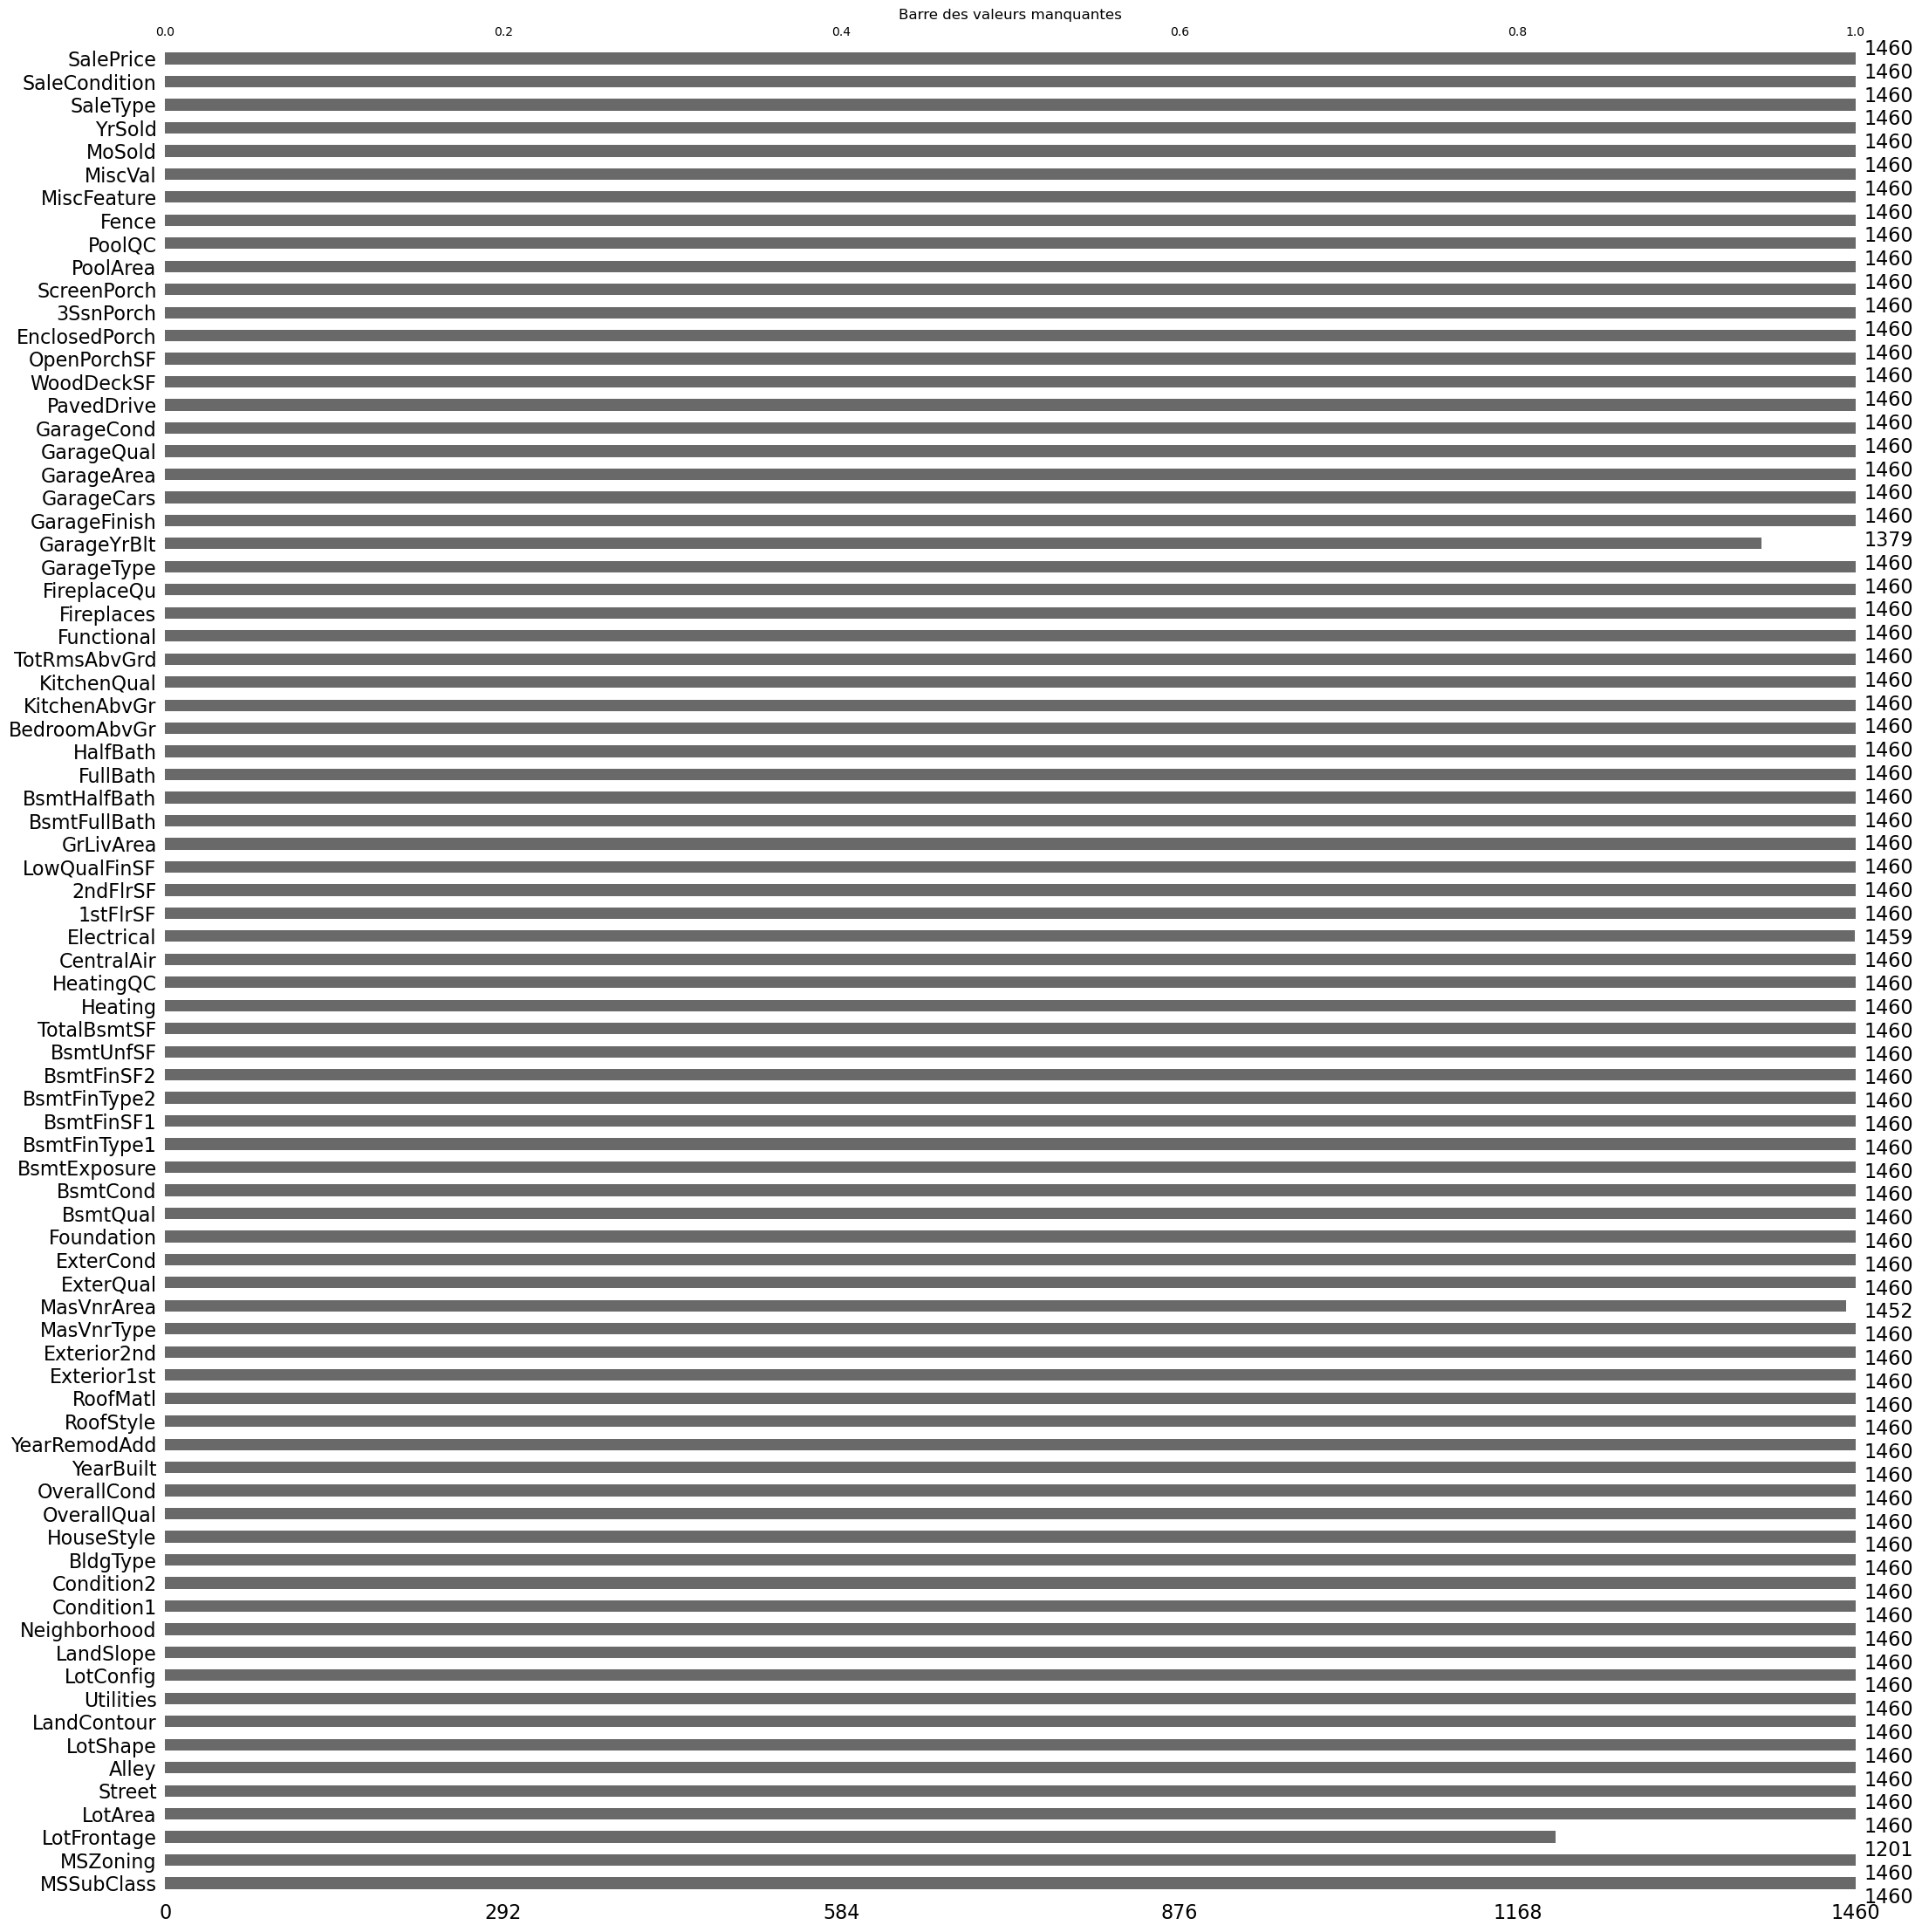

,Total,Percent
LotFrontage,259,17.74
GarageYrBlt,81,5.55
MasVnrArea,8,0.55
Electrical,1,0.07


In [22]:
missing(train)

---
> <p style="text-align:justify;font-family:times;font-size:18px;font-style: italic;font-family:Century Schoolbook">
   Les variables considérées avant concernaient les variables qualitatives qui ont la modalité NA mais qui signifie la non applicatibilité.
   Maintenant, concernant les variables quantitives , nous pouvons déjà LotFrontage, GarageYrBlt,MasVnrArea et Electrical.
   LotFrontage compte les pieds linéaires de rue reliés à la propriété, nous allons immputer par la moyenne selon la variable neighborhood.
   GarageYrBlt concerne l'année de construction du garrage et les données manquantes sont justes l'absence de GarrageYrBlt; elles seront remplacées par 0.
   MasVnrArea qui mésure la surface de maçonnerie en pieds carrés, sera juste remplacé par 0 . Quant à Electrical qui représente le système électrique, la seule donnée sera remplacée par 'Sbrkr'. </p>
---

In [24]:
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform( lambda x: x.fillna(x.mean()))
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
train['Electrical'] = train['Electrical'].fillna("SBrkr") 

<Figure size 1000x600 with 0 Axes>

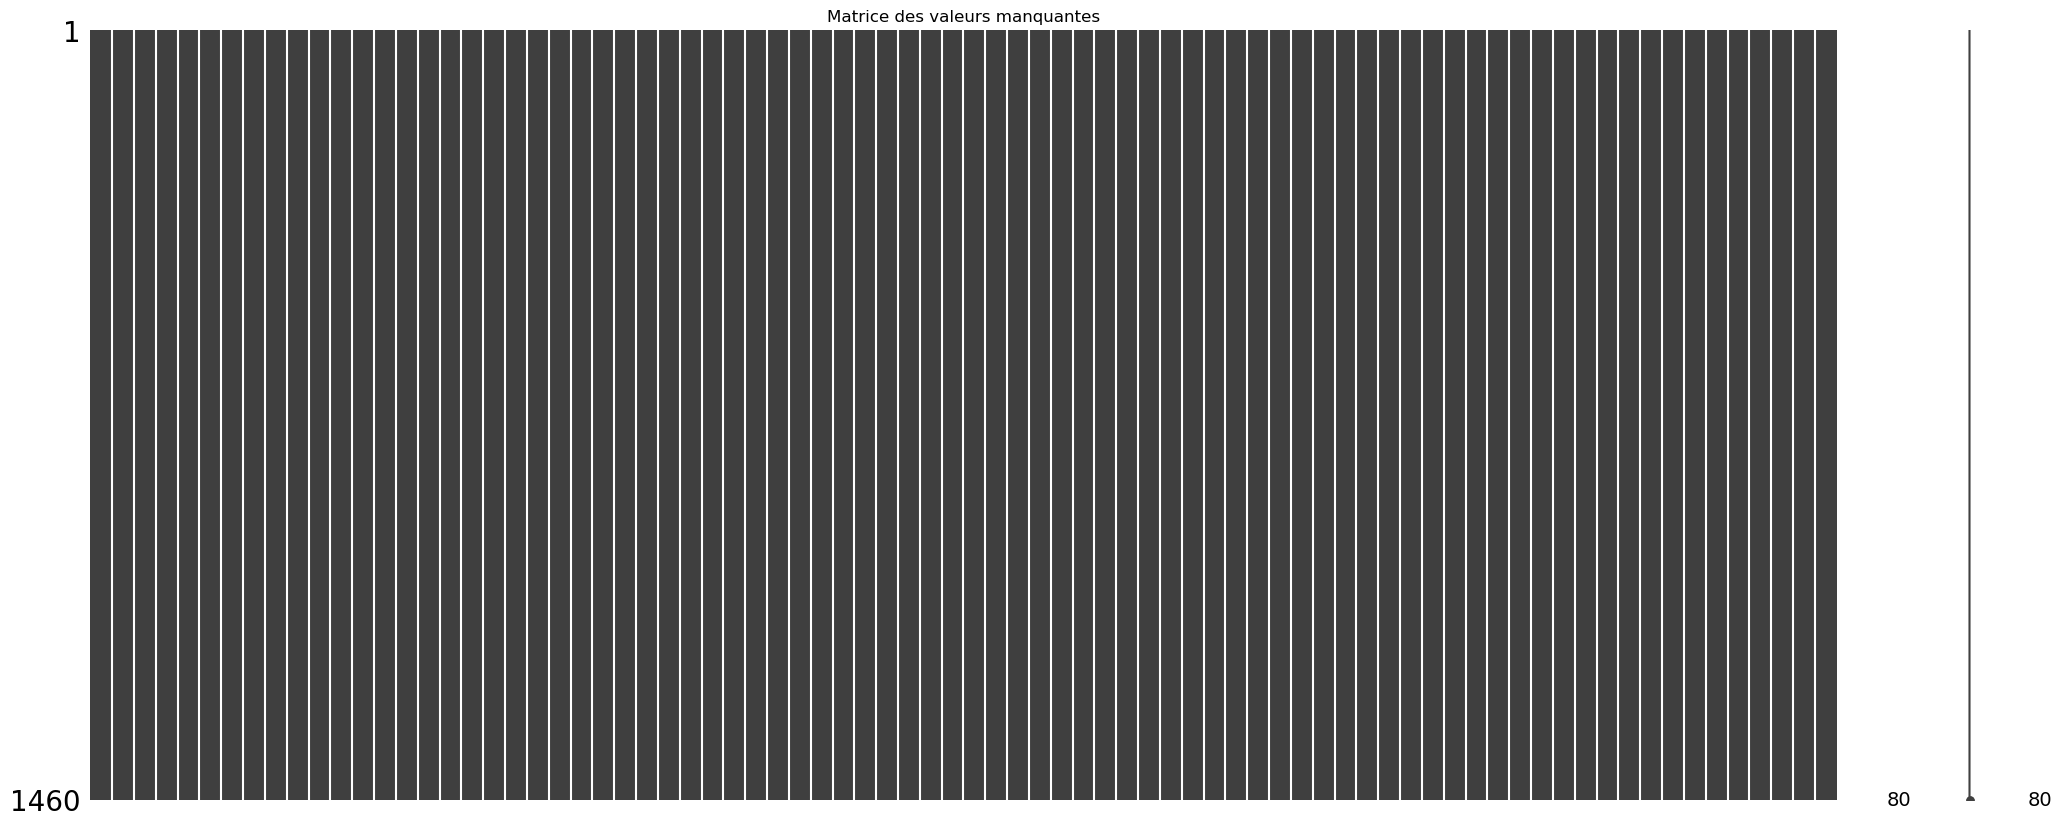

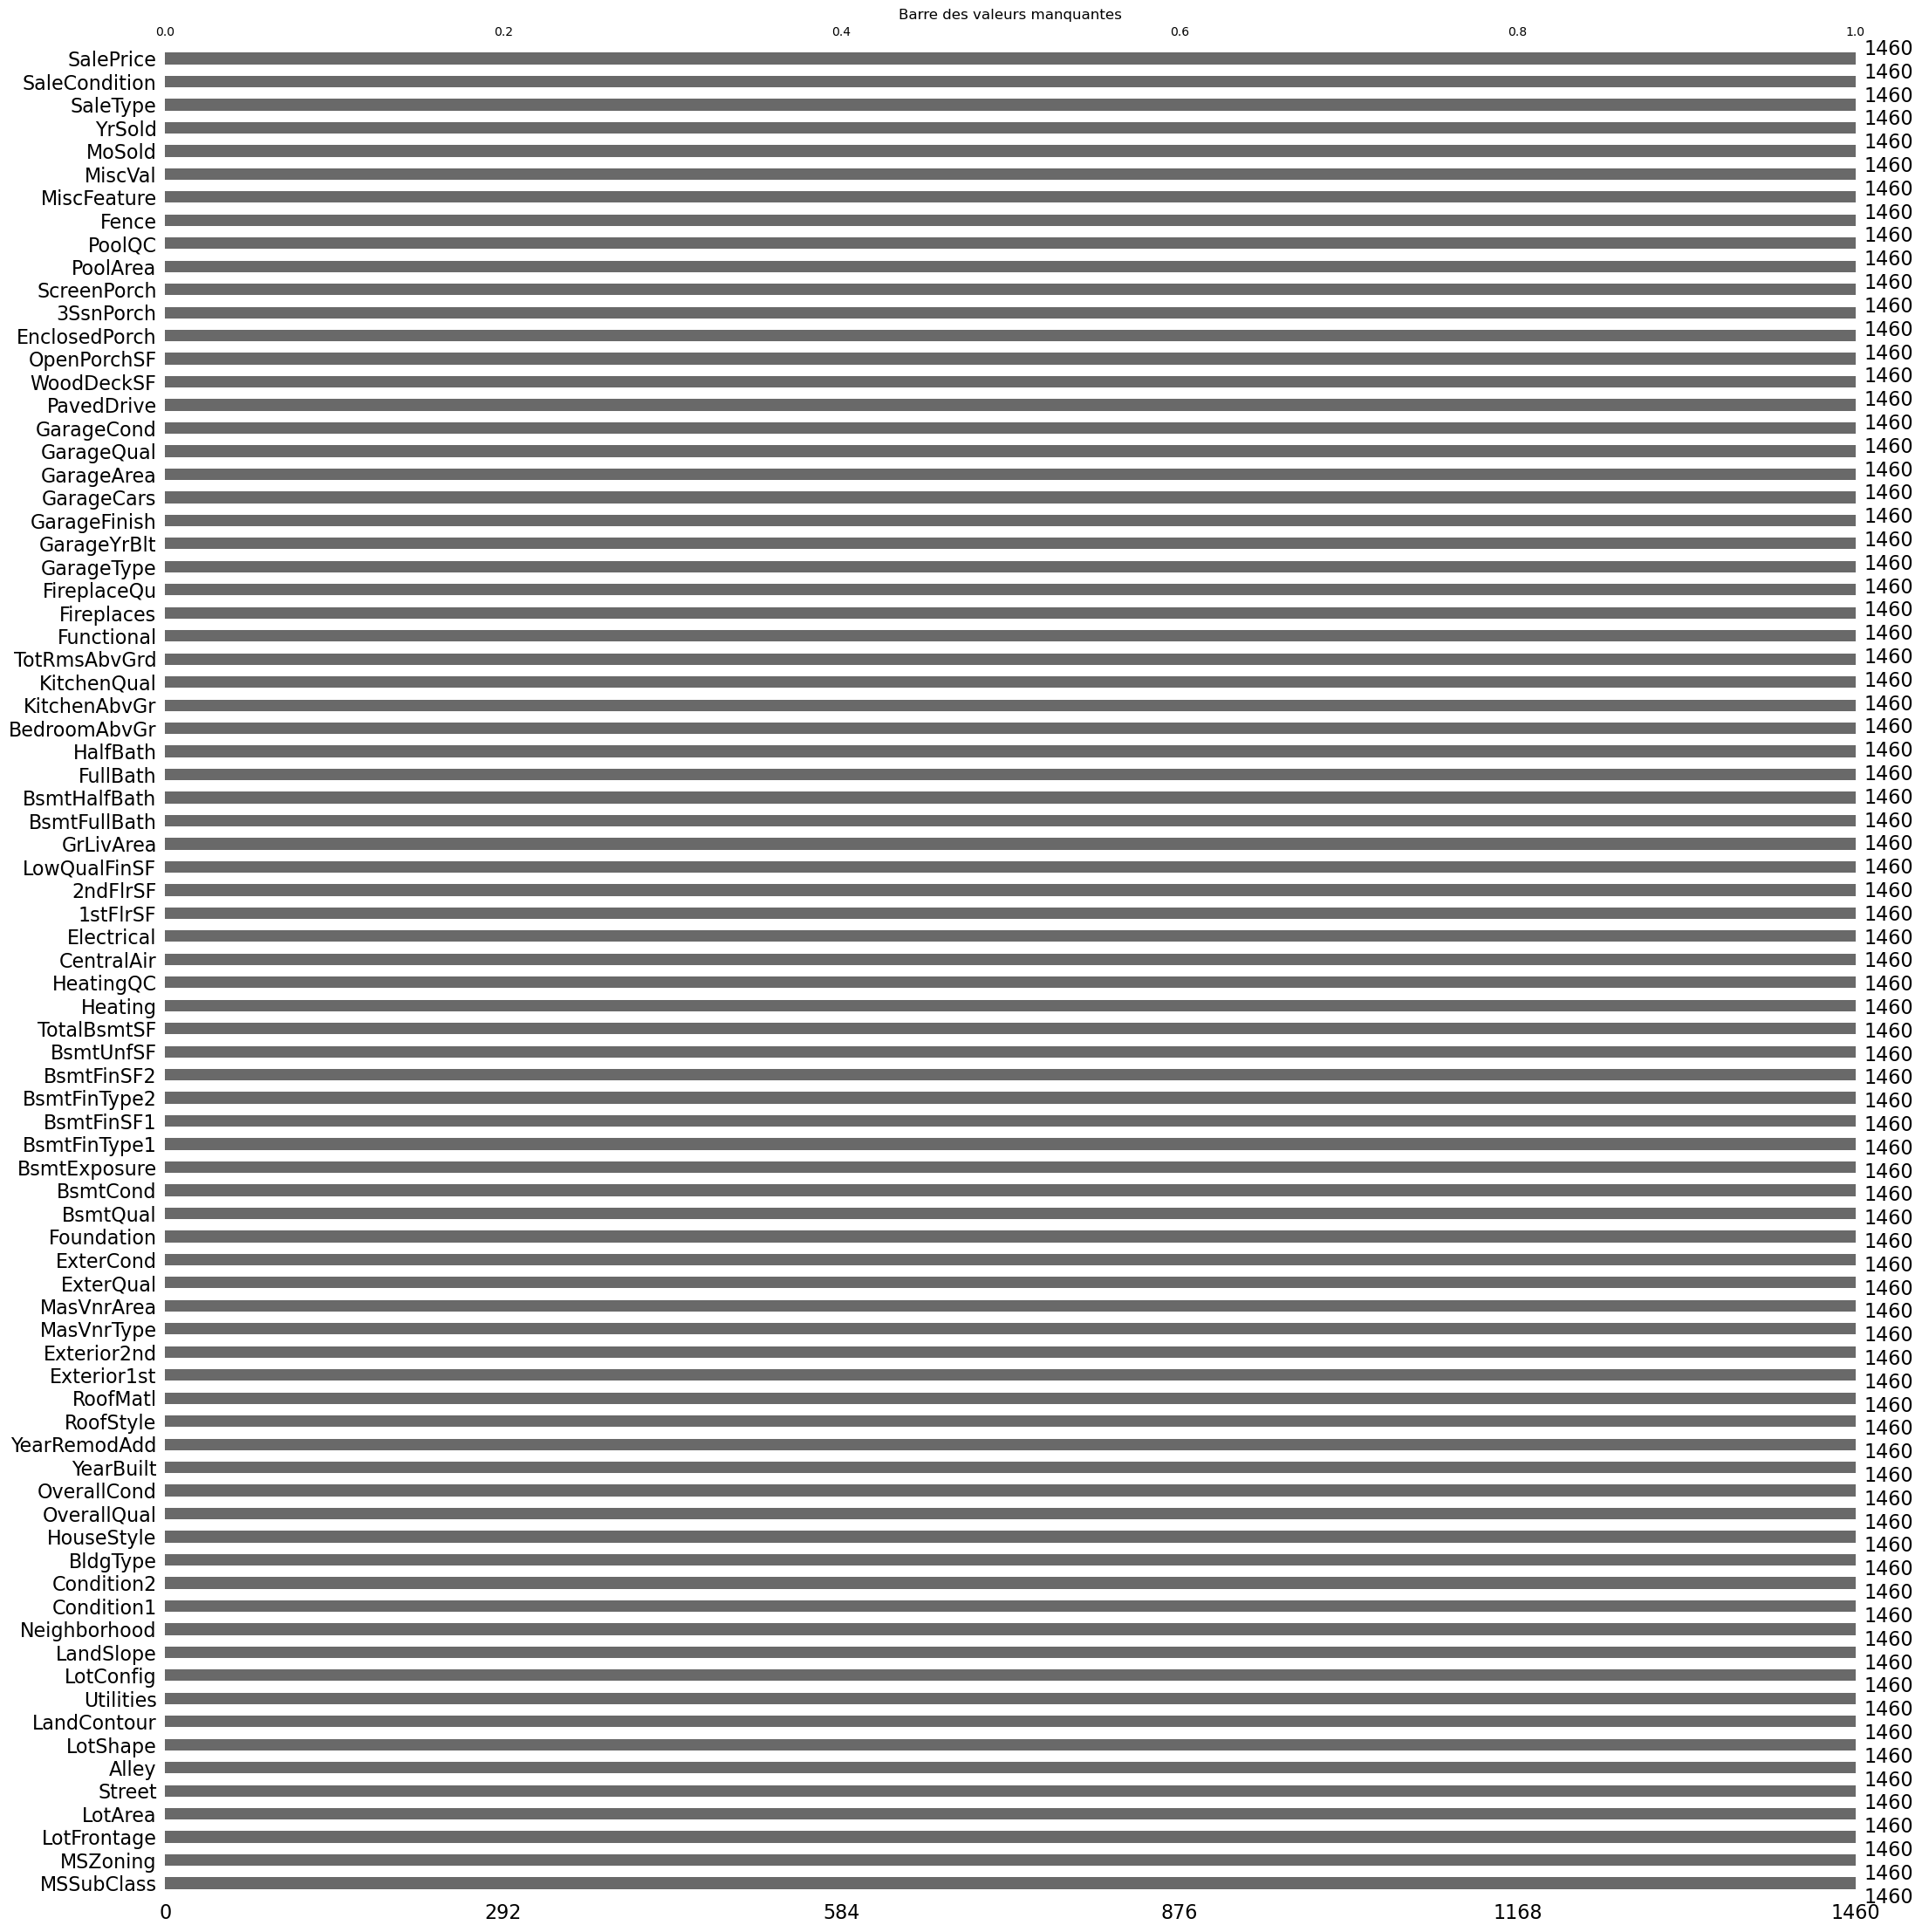

,Total,Percent


In [25]:
missing(train)

> <p style="text-align:justify;font-family:times;font-size:18px;font-style: italic;font-family:Century Schoolbook">
 Super, nous n'avons pas plus de données manquantes. </p>

In [27]:
train['YrSold'] = train['YrSold'].astype(str)
train['MoSold'] = train['MoSold'].astype(str)

In [28]:
train.to_csv("../data/train_cleand.csv")

<h2 style="text-align:justify;color:bright;font-size:30px;font-family:TIMES NEW ROMAN">IV. ANALYSE DES DONNEES</h2>

<h2 style="text-align:justify;color:bright;font-size:30px;font-family:TIMES NEW ROMAN">IV.1. ANALYSE UNIVARIEE</h2>

In [31]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.000000,70.00,190.0
LotFrontage,1460.0,70.725218,22.426978,21.0,60.00,70.083333,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.500000,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.000000,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.000000,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.000000,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.000000,2004.00,2010.0
MasVnrArea,1460.0,103.117123,180.731373,0.0,0.00,0.000000,164.25,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.500000,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.000000,0.00,1474.0


In [32]:
train_num = train.select_dtypes(include = ['float64', 'int64'])
train_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,2,548,0,61,0,0,0,0,0,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,2,460,298,0,0,0,0,0,0,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,2,608,0,42,0,0,0,0,0,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,3,642,0,35,272,0,0,0,0,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,3,836,192,84,0,0,0,0,0,250000


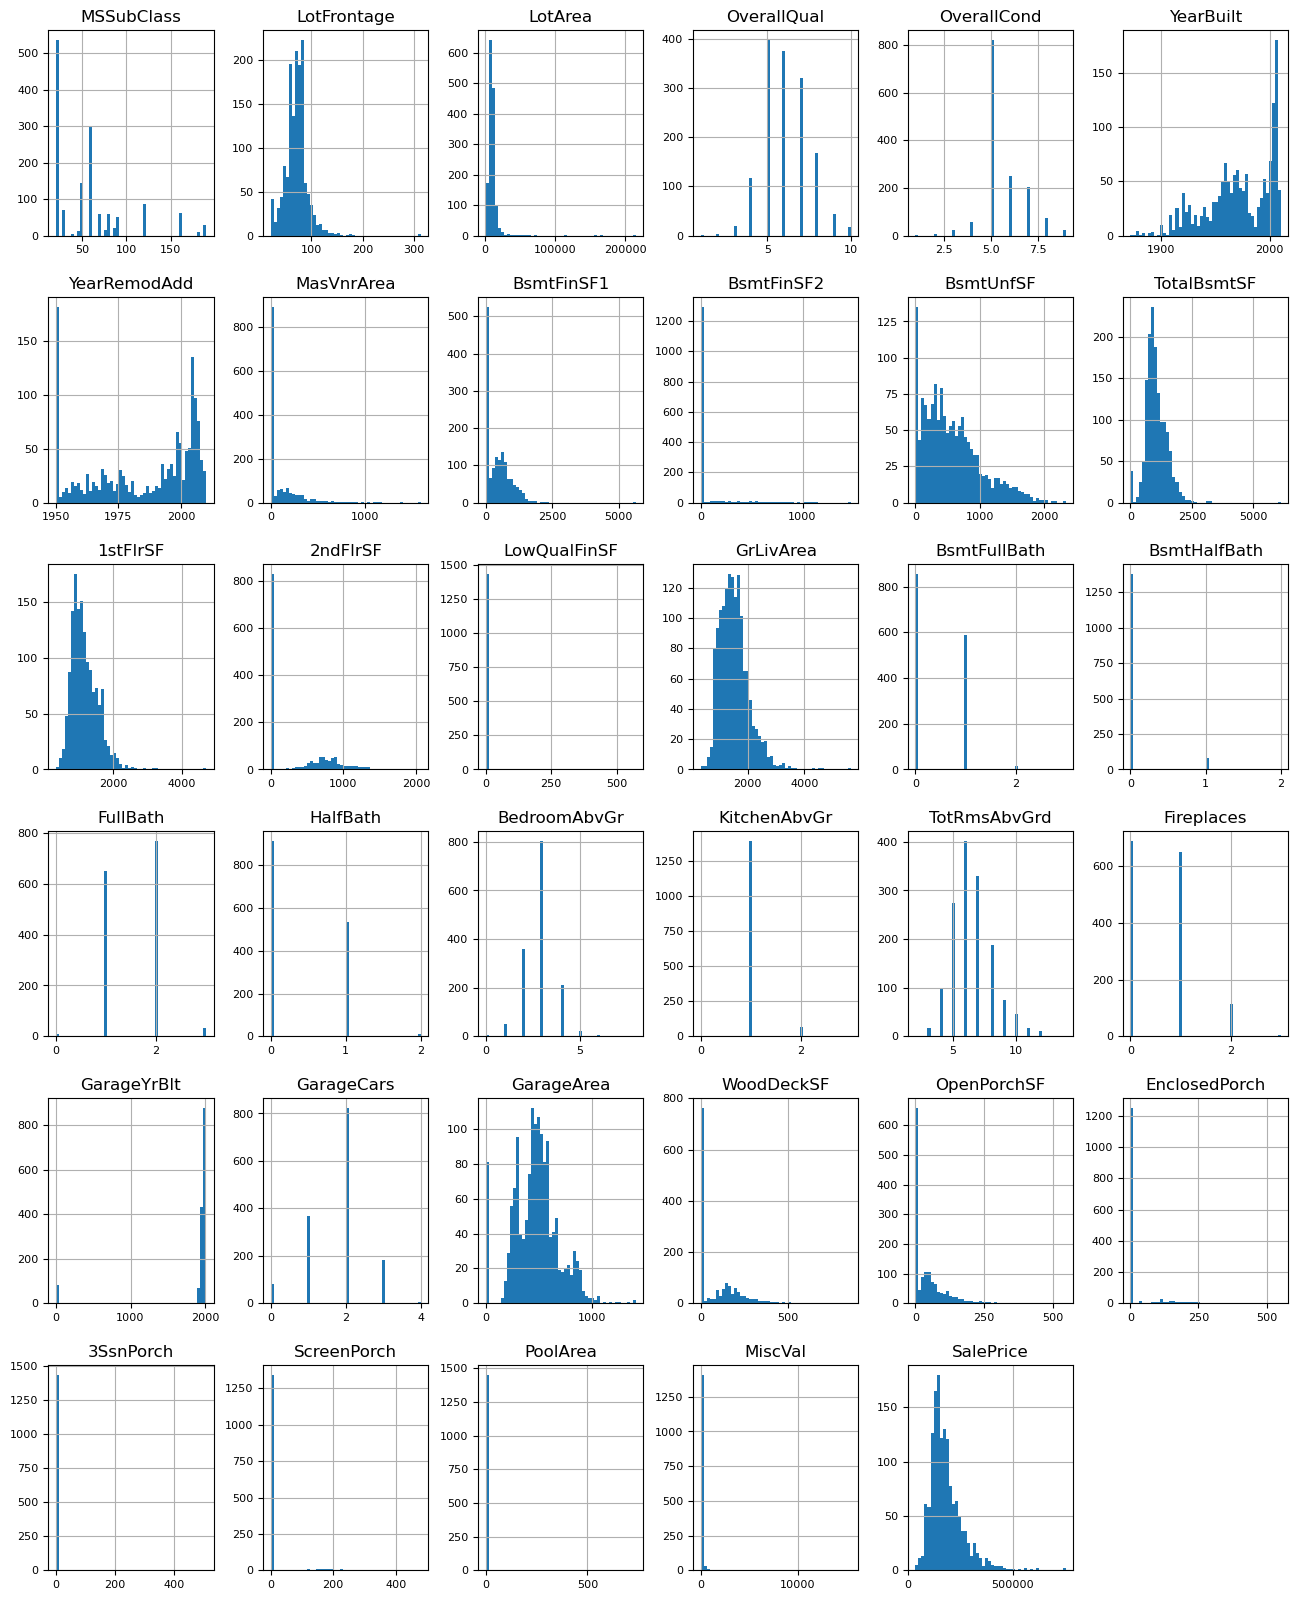

In [33]:
train_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

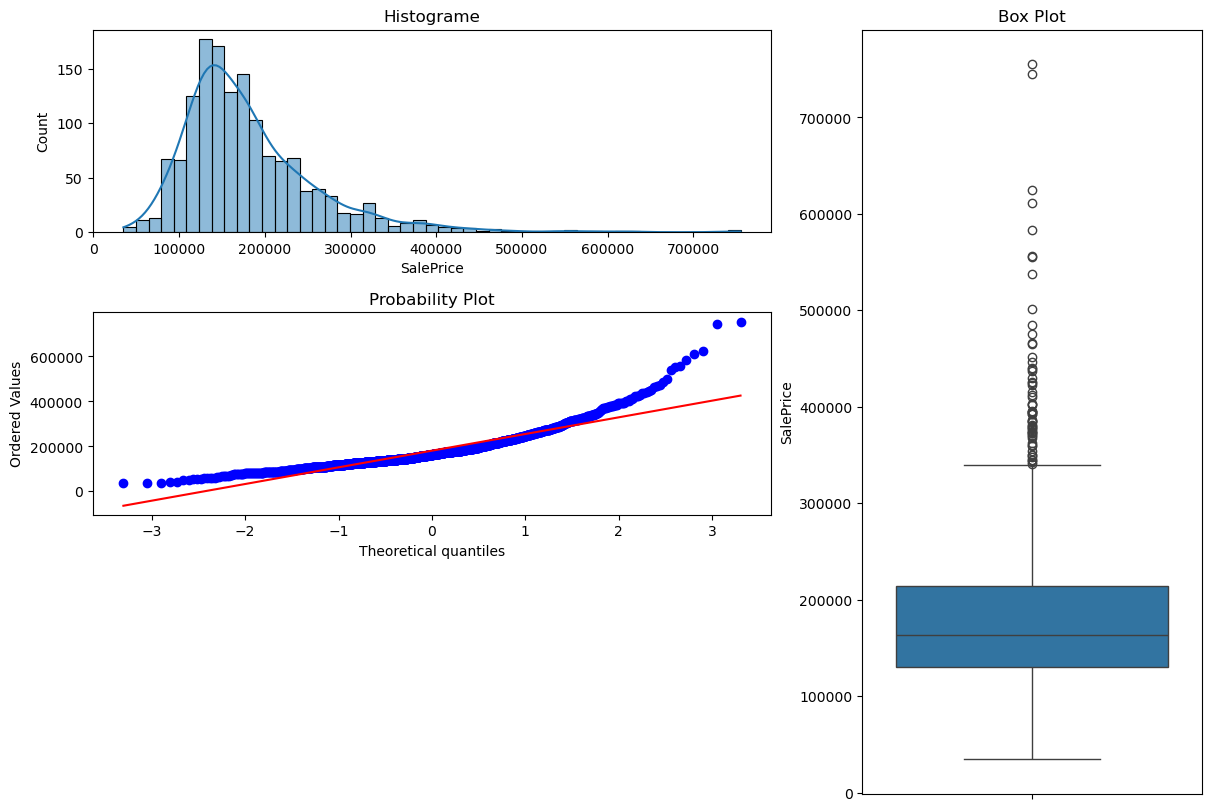

In [34]:
def plotting_3_chart(df, feature):
    fig = plt.figure(constrained_layout=True, figsize=(12, 8))
    grid = plt.GridSpec(ncols=3, nrows=3, figure=fig)

    ax1 = fig.add_subplot(grid[0, :2])
    ax1.set_title('Histograme')
    sns.histplot(df[feature], kde=True, ax=ax1)

    ax2 = fig.add_subplot(grid[1, :2])
    ax2.set_title('QQ Plot')
    stats.probplot(df[feature], plot=ax2)

    ax3 = fig.add_subplot(grid[:, 2])
    ax3.set_title('Box Plot')
    sns.boxplot(y=df[feature], ax=ax3)

    plt.show()
    
plotting_3_chart(train, 'SalePrice')


<h2 style="text-align:justify;color:bright;font-size:30px;font-family:TIMES NEW ROMAN">IV.2. ANALYSE BIVARIEE</h2>

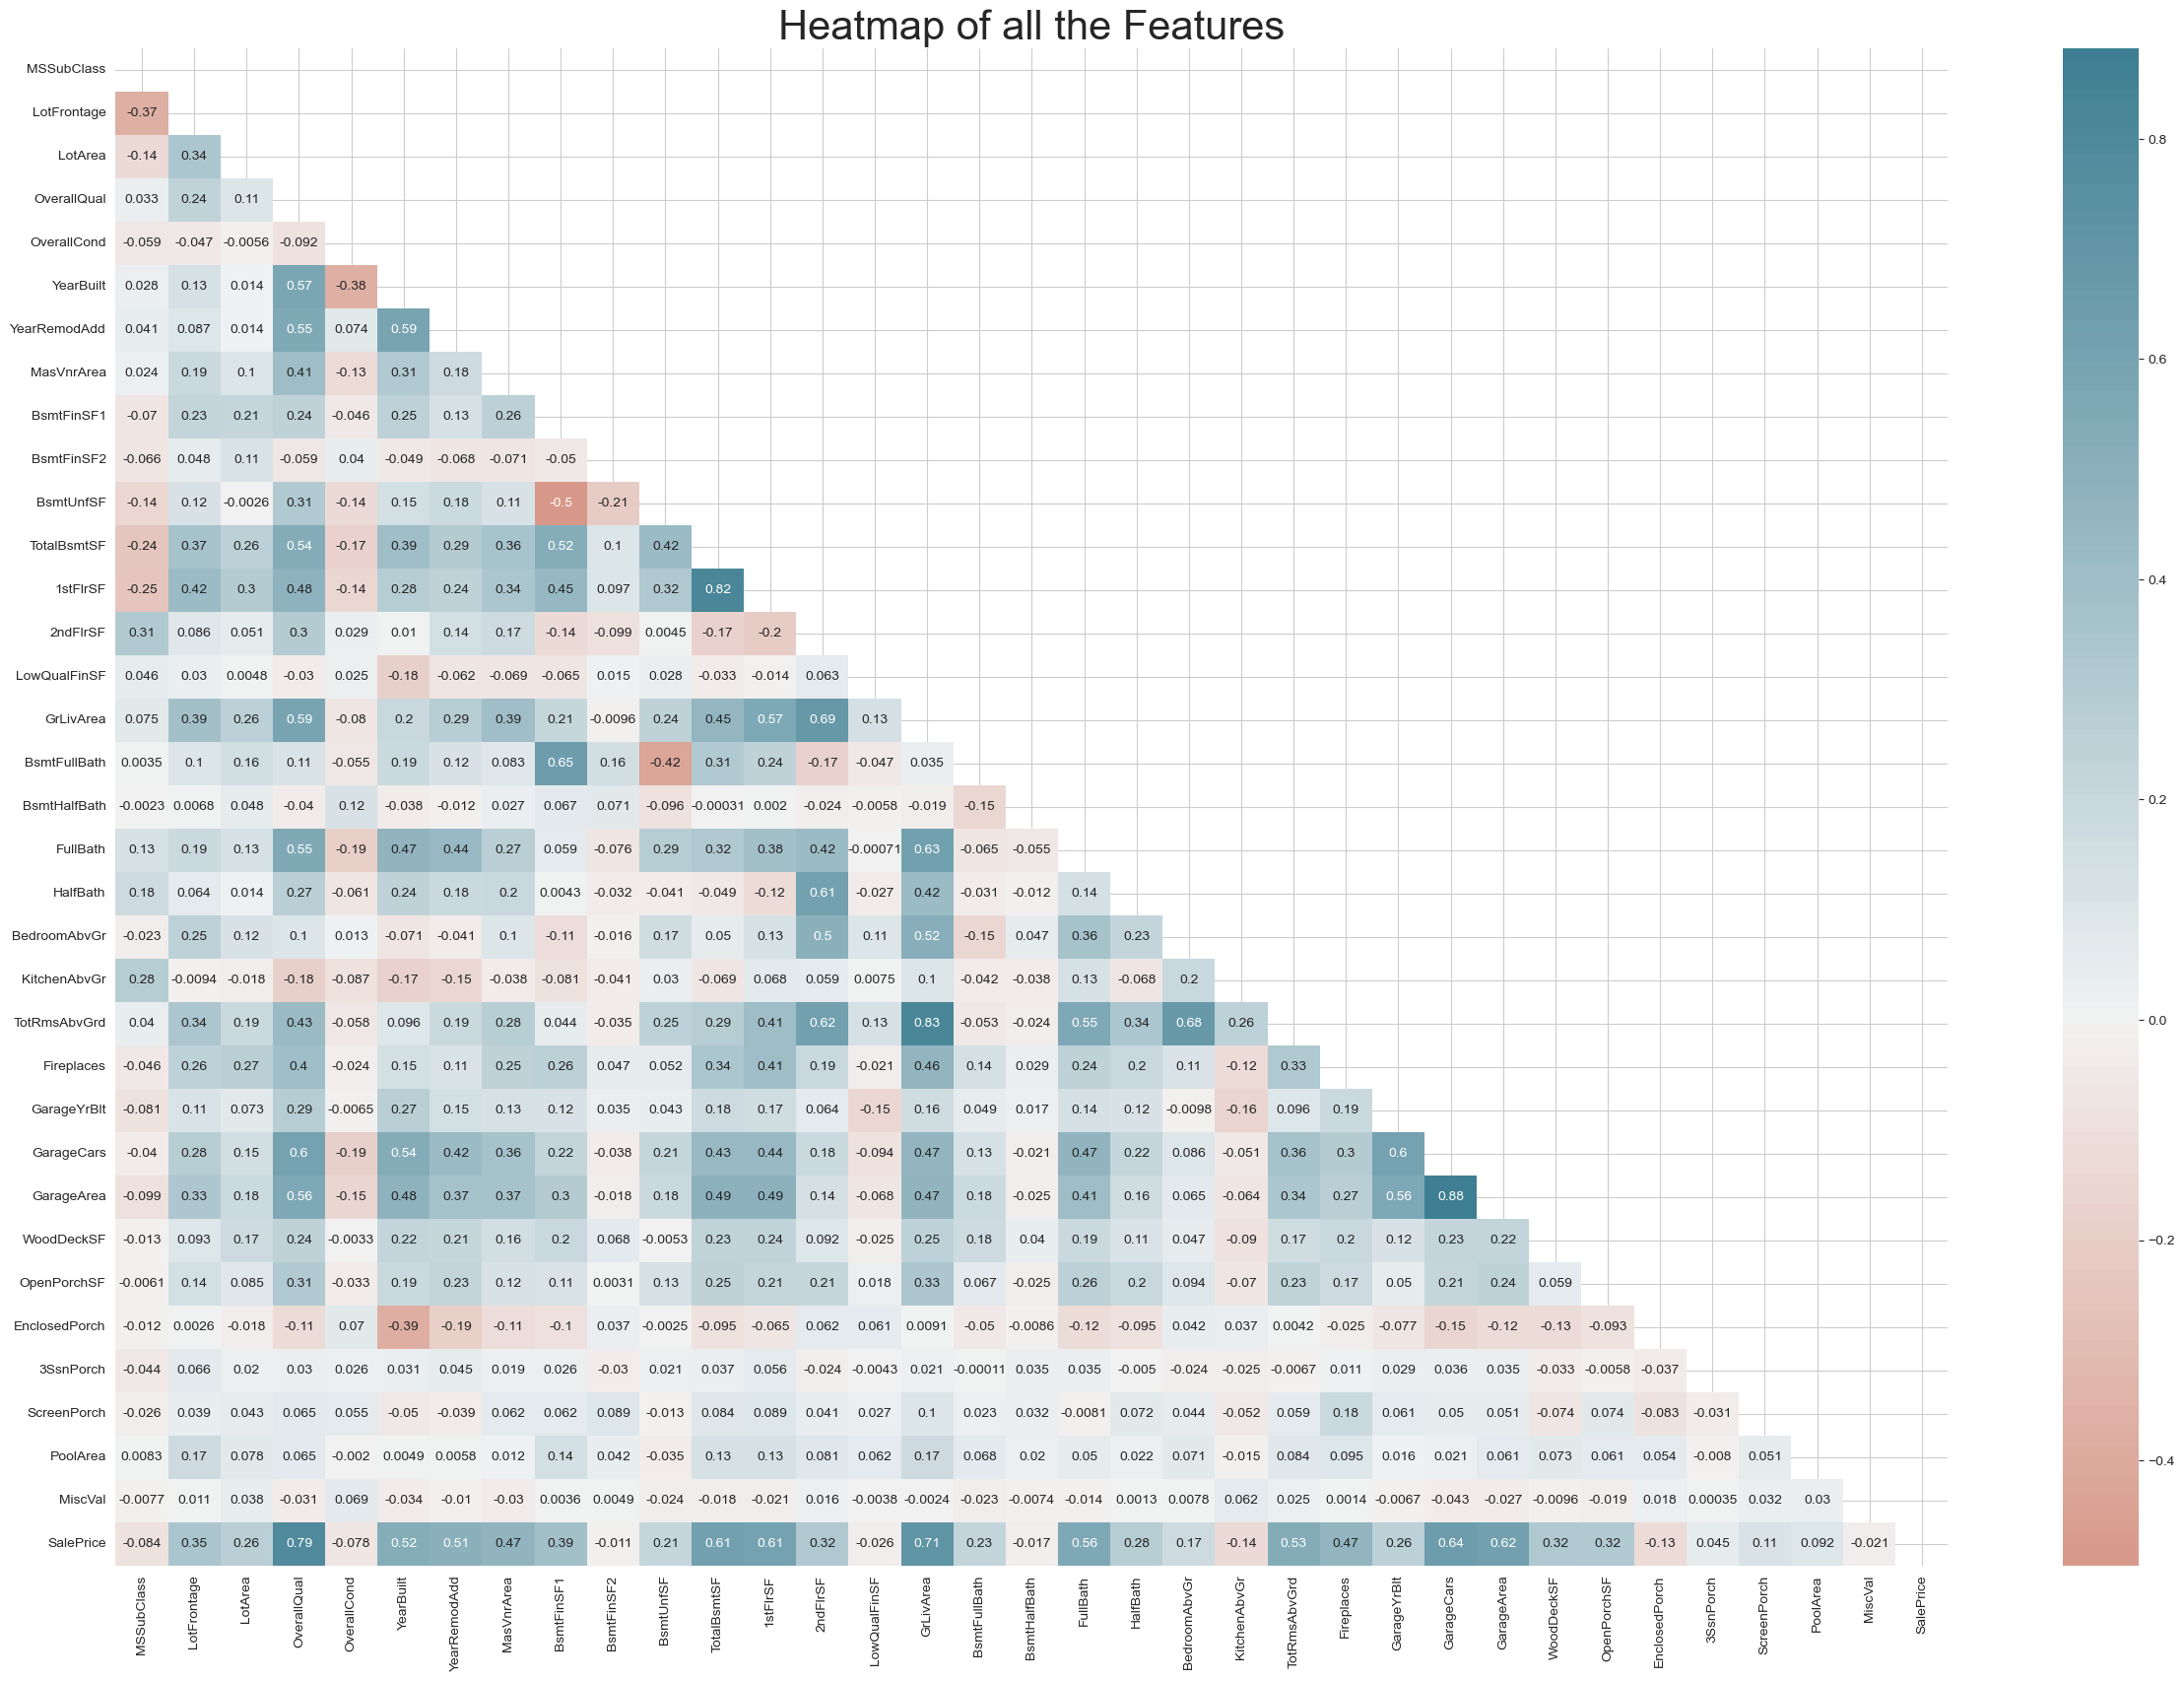

In [36]:
# Select only numeric columns
train_numeric = train.select_dtypes(include=[np.number])

# Set the plot style
sns.set_style('whitegrid')
plt.subplots(figsize=(30, 20))

# Generate a mask for the upper triangle (taken from seaborn example gallery)
mask = np.zeros_like(train_numeric.corr(), dtype=bool)  # Use bool instead of np.bool
mask[np.triu_indices_from(mask)] = True

# Plot the heatmap for numeric columns only
sns.heatmap(train_numeric.corr(), 
            cmap=sns.diverging_palette(20, 220, n=200), 
            mask=mask, 
            annot=True, 
            center=0)

# Add title
plt.title("Heatmap of all the Features", fontsize=30)

# Show the plot
plt.show()

<h2 style="text-align:justify;color:bright;font-size:30px;font-family:TIMES NEW ROMAN">IV.3. ANALYSE MULTIIVARIEE</h2>